In [8]:
import xarray as xr
import numpy as np
import datetime
import pandas as pd
import matplotlib
from shapely import LineString
import matplotlib.pyplot as plt
from matplotlib import cm
from shapelysmooth import chaikin_smooth
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Rectangle, Wedge
from matplotlib.ticker import FormatStrFormatter
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm
#import seaborn as sns
#colors : continents, oceans, wedge/graph, active
mcolors = ['#0d1b2a','#415a77','#ffffff','#8ecae6']
float_color = [255./255,255./255,255./255]
#mcolors = ['#38a3a5','#251f47','#c9ffe2','#38a3a5']

In [24]:
year_to_process = np.datetime64('2024')

In [25]:
DS=xr.open_dataset('Argo_world_full_202504.nc')
DST=xr.Dataset({'latitude':('time',DS.latitude.values),
                'longitude':('time',DS.longitude.values),
                'platform_number':('time',DS.platform_number.values),
                'institution':('time',DS.institution.values),
               },coords={'time':DS.time.values})
DST=DST.where((DST.time>=year_to_process)&(DST.time<year_to_process+np.timedelta64(1,'Y')),drop=True)          
DST=DST.where((~np.isnan(DST.latitude))&(~np.isnan(DST.longitude)),drop=True)
DST=DST.where(DST['latitude']!=0.0,drop=True)
DST=DST.where(DST['longitude']!=0.0,drop=True)
# number of floats deployed in year
deployed = len(DST.groupby('platform_number').first().platform_number)
# number of profiles in year
profiles = len(DST.time)
print(deployed,profiles)
DST

4692 167879


<xarray.Dataset> Size: 5MB
Dimensions:          (time: 167879)
Coordinates:
  * time             (time) datetime64[ns] 1MB 2024-01-01T00:02:00 ... 2024-1...
Data variables:
    latitude         (time) float32 672kB 36.92 -56.17 -3.507 ... -20.67 -35.86
    longitude        (time) float32 672kB 18.04 -173.1 -172.3 ... 85.5 27.38
    platform_number  (time) float64 1MB 5.907e+06 5.907e+06 ... 6.904e+06
    institution      (time) object 1MB 'IF' 'AO' 'AO' 'AO' ... 'IF' 'CS' 'IF'

In [26]:
platf=np.unique(DST.platform_number.values)  
platf

array([1901514., 1901701., 1901727., ..., 7902257., 7902258., 7902287.],
      shape=(4692,))

In [18]:
def gen_LineObj(pl):
    DS1b=DST.where(DST.platform_number.isin([pl]),drop=True)
    if(len(DS1b.time)>1):     
        A = ccrs.Spilhaus().transform_points(ccrs.PlateCarree(), DS1b.longitude.values, DS1b.latitude.values )          
        Di=np.sqrt((A[0:-1,0]-A[1:,0])**2+(A[0:-1,1]-A[1:,1])**2)
        if np.max(Di)<500000:
            A = ccrs.Spilhaus().transform_points(ccrs.PlateCarree(), DS1b.longitude.values, DS1b.latitude.values )            
            B = LineString(A[:,0:2])
            C = chaikin_smooth(B)
            return C
        else :
            pass        
    else:
        pass

In [27]:
import multiprocessing
#DATE TO PROCESS
pool = multiprocessing.Pool()       
#data = pool.map(gen_traj, platf)
data = pool.map(gen_LineObj, platf)
pool.close()
pool.join()

In [28]:
data = np.array(data)
data = data[data!=None]
data

array([<LINESTRING (-1334500.134 2829364.709, -1334266.321 2829477.936, -1334253.39...>,
       <LINESTRING (-401348.804 842879.449, -409981.06 839648.501, -410498.931 8394...>,
       <LINESTRING (-3397080.273 1337097.746, -3396189.849 1331509.047, -3396132.36...>,
       ...,
       <LINESTRING (719057.375 2677237.885, 725784.632 2664342.636, 726219.355 2663...>,
       <LINESTRING (1600016.089 -2291629.812, 1600286.76 -2292196.746, 1600304.62 -...>,
       <LINESTRING (-4673990.191 5226295.229, -4673990.191 5226295.229, -4673990.19...>],
      shape=(4605,), dtype=object)

In [22]:
def colorize_line(geometry):    
    return {'facecolor': 'none', 'edgecolor': float_color, 'linewidth':.2}

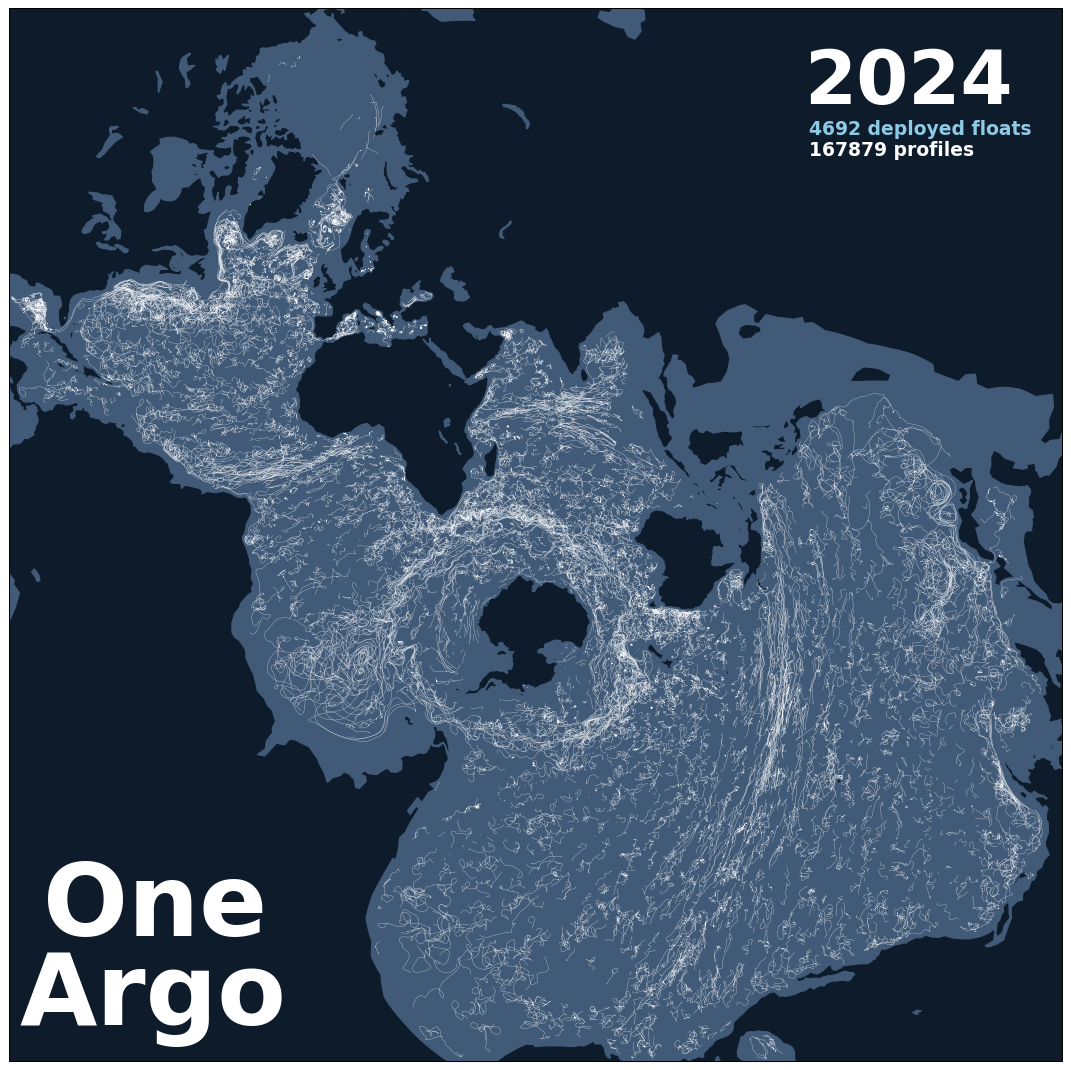

In [31]:
# PLOT
fig = plt.figure(figsize=(25,12),dpi=90)
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Spilhaus())
ax.set_global()
ax.add_feature(cfeature.LAND,facecolor=mcolors[0],edgecolor=mcolors[0])
ax.add_feature(cfeature.OCEAN,facecolor=mcolors[1],edgecolor=mcolors[1])
ax.add_feature(cfeature.LAKES,facecolor=mcolors[1],edgecolor=mcolors[1])    

ax.text(0.0325,0.12,'One',weight='bold', size=80, color=mcolors[2], transform=ax.transAxes)
ax.text(0.01,0.035,'Argo',weight='bold', size=80, color=mcolors[2], transform=ax.transAxes)
ax.text(0.755,0.91,str(year_to_process),weight='bold', size=60, color=mcolors[2], transform=ax.transAxes)
ax.text(0.76,0.88,str(int(deployed))+' deployed floats',weight='bold', size=15, color=mcolors[3], transform=ax.transAxes)
ax.text(0.76,0.86,str(int(profiles))+' profiles',weight='bold', size=15, color=mcolors[2], transform=ax.transAxes)

ax.add_geometries(data, ccrs.Spilhaus(),styler=colorize_line)

plt.tight_layout()   
#plt.show()
plt.savefig('EK_24.png')